<a href="https://colab.research.google.com/github/joiepark/assignment_esaa/blob/main/YB%209.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 규제 선형 모델 - 릿지, 라쏘, 엘라스틱넷

### 규제 선형 모델의 개요


*   회귀 모델은 적절히 데이터에 적합하면서도 회귀 계수가 기하급수적으로 커지는 것을 제어할 수 있어야 한다. 이전까지 선형 모델의 비용 함수는 RSS를 최소화하는, 즉 실제 값과 예측값의 차이를 최소화하는 것만 고려했다. 그러다 보니 학습 데이터에 지나치게 맞추게 되고, 회귀 계수가 쉽게 커졌다. 이럴 경우 변동성이 오히려 심해져서 테스트 데이터 세트에서는 예측 성능이 저하되기 쉽다. 이를 반영해 비용 함수는 학습 데이터의 잔차 오류 값을 최소로 하는 RSS 최소화 방법과 과적합을 방지하기 위해 회귀 계수 값이 커지지 않도록 하는 방법이 서로 균형을 이뤄야 한다. 이렇게 회귀 계수의 크기를 제어해 과적합을 개선하려면 비용 함수의 목표가 다음과 같이 변경되어야 한다. 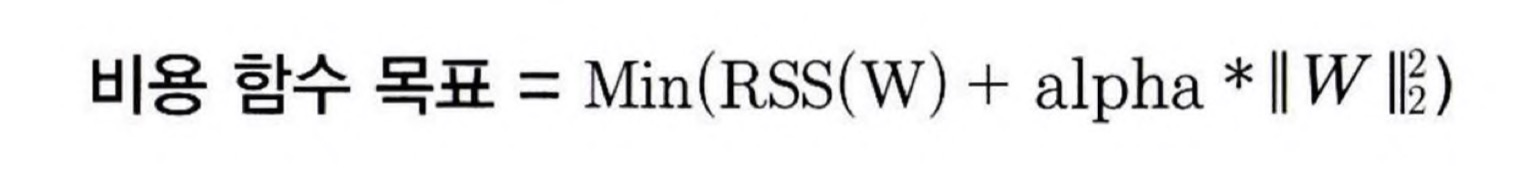





*   여기서 alpha는 학습 데이터 적합 정도와 회귀 계수 값의 크기를 제어하는 역할을 하는 튜닝 파라미터이다. alpha가 0 또는 매우 작은 값이라면, 비용 함수 식은 기존과 동일한 Min(RSS(W) + 0)이 될 것이다. 반면에 alpha가 무한대 또는 매우 큰 값이라면 비용 함수식은 너무 커지게 되므로 W 값을 9 또는 매우 작게 만들어야 Cost가 최소화되는 비용 함수 목표를 달성할 수 있다. 즉, alpha 값을 크게 하면 비용 함수는 회귀 계수 W의 값을 작게 해 과적합을 개선할 수 있으며, alpha 값을 작게 하면 회귀 계수 W의 값이 커져도 어느 정도 상쇄가 가능하므로 학습 데이터 적합을 더 개선할 수 있다. alpha를 0에서부터 지속적으로 값을 증가시키면 회귀 계수 값의 크기를 감소시킬 수 있는 것이다.
*   이처럼 비용 함수에 alpha 값으로 페널티를 부여해 회귀 계수 값의 크기를 감소시켜 과적합을 개선하는 방식을 규제(Regulation)라고 부른다. 규제는 크게 L2 방식과 L1 방식으로 구분된다. L2 규제는 W의 제곱에 대해 페널티를 부여하는 방식을 말하고, L2 규제를 적용한 회귀를 릿지(Ridge) 회귀라고 한다. 라쏘(Lasso 회귀)는 L1 규제를 적용한 회귀이다. L1 규제는 W의 절댓값에 대해 페널티를 부여한다. L1 규제를 적용하면 영향력이 크지 않은 회귀 계수 값을 0으로 변환한다.



### 릿지 회귀


*   사이킷런은 Ridge 클래스를 통해 릿지 회귀를 구현한다. Ridge 클래스의 주요 생성 파라미터는 alpha이며, 이는 릿지 회귀의 alpha L2 규제 계수에 해당한다.
*   항목 추가



In [13]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
X_data = pd.DataFrame(data, columns=feature_names)
y_target = pd.Series(target, name='PRICE')

In [14]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score   ## 앞 예제의 보스턴 주택 가격을 Ridge 클래스를 이용해 다시 예측하고, 예측 성능을 cross_val_score()로 평가한다

## alpha=10으로 설정해 릿지 회귀를 수행한다
ridge = Ridge(alpha=16)
neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring="neg_mean_squared_error", cv=5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print('5 folds의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 3))
print('5 folds의 개별 RMSE scores: ', np.round(rmse_scores, 3))
print('5 folds의 평균 RMSE: {0:.3f}'.format(avg_rmse))

5 folds의 개별 Negative MSE scores:  [-11.54  -24.569 -28.669 -71.35  -27.572]
5 folds의 개별 RMSE scores:  [3.397 4.957 5.354 8.447 5.251]
5 folds의 평균 RMSE: 5.481


릿지의 5개 폴드 세트의 평균 RMSE는 5.481로, 앞 예제의 규제가 없는 LinearRegression의 RMSE 평균인 5.829보다 더 뛰어난 예측 성능을 보인다.

In [15]:
## 릿지의 alpha값을 0, 0.1, 1, 10, 100으로 변화시키면서 RMSE와 회귀 계수 값의 변화를 살펴본다

## 릿지에 사용될 alpha 파라미터의 값을 정의한다
alphas = [0, 0.1, 1, 10, 100]

## alphas list 값을 반복하면서 alpha에 따른 평균 RMSE를 구한다
for alpha in alphas :
  ridge = Ridge(alpha = alpha)
  ## cross_val_score를 이용해 5 폴드의 평균 RMSE를 계산한다
  neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring="neg_mean_squared_error", cv=5)
  avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
  print('alpha {0} 일 때 5 folds의 평균 RMSE: {1:.3f}'.format(alpha, avg_rmse))

alpha 0 일 때 5 folds의 평균 RMSE: 5.829
alpha 0.1 일 때 5 folds의 평균 RMSE: 5.788
alpha 1 일 때 5 folds의 평균 RMSE: 5.653
alpha 10 일 때 5 folds의 평균 RMSE: 5.518
alpha 100 일 때 5 folds의 평균 RMSE: 5.330


alpha가 100일 때 평균 RMSE가 5.330으로 가장 좋다.

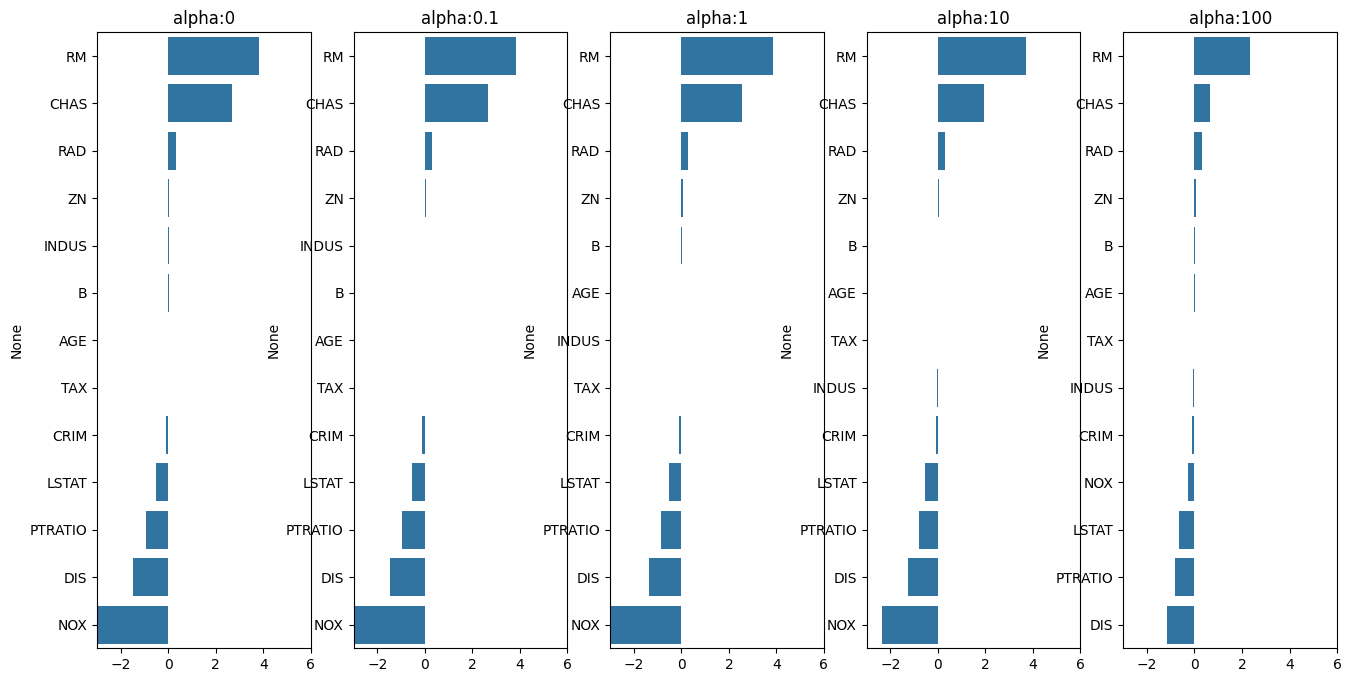

In [16]:
## 릿지의 alpha값의 변화에 따른 피처의 회귀 계수 값을 가로 막대 그래프로 시각화한다

## 각 alpha에 따른 회귀 계수 값을 시각화하기 위해 5개의 열로 된 맷플롯립 축을 생성한다
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
fig, axs = plt.subplots(figsize=(16, 8), nrows=1, ncols=5)
## 각 alpha에 따른 회귀 계수 값을 데이터로 저장하기 위한 DataFrame을 생성한다
coeff_df = pd.DataFrame()

## alphas 리스트 값을 차례로 입력해 회귀 계수 값을 시각화하고 데이터를 저장한다
for pos, alpha in enumerate(alphas):
  ridge = Ridge(alpha=alpha)
  ridge.fit(X_data, y_target)
  ## alpha에 따른 피처별로 회귀 계수를 Series로 변환하고 이를 DataFrame의 칼럼으로 추가한다
  coeff = pd.Series(data=ridge.coef_, index=X_data.columns)
  colname = 'alpha:'+str(alpha)
  coeff_df[colname] = coeff
  ## 막대 그래프로 각 alpha 값에서의 회귀 계수를 시각화한다
  coeff = coeff.sort_values(ascending=False)
  axs[pos].set_title(colname)
  axs[pos].set_xlim(-3, 6)
  sns.barplot(x=coeff.values, y=coeff.index, ax=axs[pos])

## for문 밖에서 matplotlib의 show()를 호출하고 alpha에 따른 피처별 회귀 계수를 DataFrame으로 표시한다
plt.show()

alpha 값을 계속 증가시킬수록 회귀 계수 값은 지속적으로 작아짐을 알 수 있다. 특히, NOX 피처의 경우 alpha값을 계속 증가시킴에 따라 회귀 계수가 크게 작아졌다.

In [17]:
## DataFrame에 저장된 alpha 값의 변화에 따른 릿지 회귀 계수 값을 구한다
ridge_alphas = [0, 0.1, 1, 10, 100]
sort_column = 'alpha:'+str(ridge_alphas[0])
coeff_df.sort_values(by=sort_column, ascending=False)

,alpha:0,alpha:0.1,alpha:1,alpha:10,alpha:100
RM,3.809865,3.818233,3.854000,3.702272,2.334536
CHAS,2.686734,2.670019,2.552393,1.952021,0.638335
RAD,0.306049,0.303515,0.290142,0.279596,0.315358
ZN,0.046420,0.046572,0.047443,0.049579,0.054496
INDUS,0.020559,0.015999,-0.008805,-0.042962,-0.052826
B,0.009312,0.009368,0.009673,0.010037,0.009393
AGE,0.000692,-0.000269,-0.005415,-0.010707,0.001212
TAX,-0.012335,-0.012421,-0.012912,-0.013993,-0.015856
CRIM,-0.108011,-0.107474,-0.104595,-0.101435,-0.102202
LSTAT,-0.524758,-0.525966,-0.533343,-0.559366,-0.660764


alpha값이 증가하면서 회귀값이 지속적으로 작아질 수 있음을 알 수 있다.

*   alpha가 100일 때 평균 RMSE가 5.330으로 가장 좋다.

### 라쏘 회귀
*   W의 절댓값에 페널티를 부여하는 L1 규제를 선형 회귀에 적용한 것이 라쏘(Lasso) 회귀이다. 즉 L1 규제는 alpha * ||W||1을 의미하며, 라쏘 회귀 비용함수의 목표는 RSS(W) + alpha * ||W||1 식을 최소화하는 W를 찾는 것이다. L2 규제가 회귀 계수의 크기를 감소시킴에 반해, L1 규제는 불필요한 회귀 계수를 급격히 감소시켜 0으로 만들고 제거한다. 이러한 측면에서 L1 규제는 적절한 피처만 회귀에 포함시키는 피처 선택의 특성을 가진다.
*   사이킷런은 Lasso 클래스를 통해 라쏘 회귀를 구현했다. Lasso 클래스의 주요 생성 파라미터는 alpha이며, 이는 라쏘 회귀 alpha L1 규제 계수에 해당한다.





In [18]:
## 라쏘의 alpha값을 변화시키면서 RMSE와 각 피처의 회귀 계수를 출력한다
from sklearn.linear_model import Lasso, ElasticNet

## alpha값에 따른 회귀 모델의 폴드 평균 RMSE를 출력하고 회귀 계수값들을 DataFrame으로 변환하는 함수를 생성한다
def get_linear_reg_eval(model_name, params=None, X_data_n=None, y_target_n=None, verbose=True, return_coeff=True):
  coeff_df = pd.DataFrame()
  if verbose : print('####### ', model_name, '#######')
  for param in params:
    if model_name == 'Ridge': model = Ridge(alpha=param)
    elif model_name == 'Lasso': model = Lasso(alpha=param)
    elif model_name == 'ElasticNet': model = ElasticNet(alpha=param, l1_ratio=0.7)
    neg_mse_scores = cross_val_score(model, X_data_n, y_target_n, scoring="neg_mean_squared_error", cv=5)
    avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
    print('alpha {0}일 때 5 폴드 세트의 평균 RMSE: {1:.3f}'.format(param, avg_rmse))
    ## cross_val_score는 evaluation metric만 반환하므로 모델을 다시 학습해 회귀 계수를 추출한다
    model.fit(X_data_n, y_target_n)
    if return_coeff:
      ## alpha에 따른 피처별 회귀 계수를 Series로 변환하고 이를 DataFrame의 칼럼으로 추가한다
      coeff = pd.Series(data=model.coef_, index=X_data_n.columns)
      colname = 'alpha:'+str(param)
      coeff_df[colname] = coeff
  return coeff_df

In [19]:
## 정의한 함수를 이용해 alpha값의 변화에 따른 RMSE와 그 때의 회귀계수들을 출력한다
## 라쏘에 사용될 alpha 파라미터의 값을 정의하고 get_linear_reg_eval() 함수를 호출한다
lasso_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_lasso_df = get_linear_reg_eval('Lasso', params=lasso_alphas, X_data_n=X_data, y_target_n=y_target)

#######  Lasso #######
alpha 0.07일 때 5 폴드 세트의 평균 RMSE: 5.612
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.615
alpha 0.5일 때 5 폴드 세트의 평균 RMSE: 5.669
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.776
alpha 3일 때 5 폴드 세트의 평균 RMSE: 6.189


alpha가 0.07일 때 5.612로 가장 좋은 평균 RMSE를 보여준다. 앞의 릿지 평균인 5.481보다는 약간 떨어지는 수치지만, LinearRegression 평균인 5.829보다는 향상됐다.

In [20]:
## alpha 값에 따른 피처별 회귀계수를 확인한다
## 반환된 coeff_lasso_df를 첫번째 칼럼순으로 내림차순으로 정렬해 회귀계수 DataFrame을 출력한다
sort_column = 'alpha:'+str(lasso_alphas[0])
coeff_lasso_df.sort_values(by=sort_column, ascending=False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
RM,3.789725,3.703202,2.498212,0.949811,0.000000
CHAS,1.434343,0.955190,0.000000,0.000000,0.000000
RAD,0.270936,0.274707,0.277451,0.264206,0.061864
ZN,0.049059,0.049211,0.049544,0.049165,0.037231
B,0.010248,0.010249,0.009469,0.008247,0.006510
NOX,-0.000000,-0.000000,-0.000000,-0.000000,0.000000
AGE,-0.011706,-0.010037,0.003604,0.020910,0.042495
TAX,-0.014290,-0.014570,-0.015442,-0.015212,-0.008602
INDUS,-0.042120,-0.036619,-0.005253,-0.000000,-0.000000
CRIM,-0.098193,-0.097894,-0.083289,-0.063437,-0.000000


alpha의 크기가 증가함에 따라 일부 피처의 회귀 계수는 아예 0으로 바뀌고 있다. NOX 속성은 alpha가 0.07일 때부터 회귀 계수가 0이며, alpha를 증가시키면서 INDUS, CHAS와 같은 속성의 회귀 계수가 0으로 바뀐다. 회귀 계수가 0인 피처는 회귀 식에서 제외되면서 피처 선택의 효과를 얻을 수 있다.

### 엘라스틱넷 회귀


*   엘라스틱넷(Elastic Net) 회귀는 L2 규제와 L1 규제를 결합한 회귀이다. 따라서 엘라스틱넷 회귀 비용함수의 목표는 RSS(W) + alpha2 * ||W||2^2 + alpha1 * ||W||1 식을 최소화하는 W를 찾는 것이다. 엘라스틱넷은 라쏘 회귀가 서로 상관관계가 높은 피처들의 경우 이들 중에서 중요 피처만을 셀렉션하고 다른 피처들은 모두 회귀 계수를 0으로 만드는 성향이 강하다. 특히 이런 성향으로 인해 alpha값에 따라 회귀 계수의 값이 급격하게 변동할 수도 있는데, 엘라스틱넷 회귀는 이를 완화하기 위해 L2 규제를 라쏘 회귀에 추가한 것이다. 반대로 엘라스틱넷 회귀의 단점은 L1과 L2 규제가 결합된 규제로 인해 수행시간이 상대적으로 오래 걸린다는 것이다.
*   사이킷런은 ElasticNet 클래스를 통해 엘라스틱넷 회귀를 구현한다. ElasticNet 클래스의 주요 생성 파라미터는 alpha와 l1_ratio이다. Elastic 클래스의 alpha와 l1_ratio이다. 엘라스틱넷의 규제는 a * L1 + b * L2로 정의될 수 있으며, 이 때 a는 L1 규제의 alpha값, b는 L2 규제의 alpha 값이다. 따라서 ElasticNet 클래스의 alpha 파라미터 값은 a+b이다. ElasticNet 클래스의 l1_ratio 파라미터 값은 a / (a+b)이다. l1_ratio가 0이면 a가 0이므로 L2 규제와 동일하고, l2_ratio가 0이면 b가 0이므로 L1 규제와 동일하다.



In [21]:
## ElasticNet 클래스를 이용해 엘라스틱넷 alpha 값을 변화시키면서 RMSE와 각 피처의 회귀 계수를 출력한다
## 엘라스틱넷에 사용될 alpha 파라미터의 값들을 정의하고 get_linear_reg_eval() 함수를 호출한다
elastic_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_elastic_df = get_linear_reg_eval('ElasticNet', params=elastic_alphas, X_data_n=X_data, y_target_n=y_target)  ## alpha값의 변화만 살피기 위해 l1_ratio를 0.7로 고정한 것

#######  ElasticNet #######
alpha 0.07일 때 5 폴드 세트의 평균 RMSE: 5.542
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.526
alpha 0.5일 때 5 폴드 세트의 평균 RMSE: 5.467
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.597
alpha 3일 때 5 폴드 세트의 평균 RMSE: 6.068


alpha가 0.5일 때 RMSE가 5.467로 가장 좋은 예측 성능을 보이고 있다.

In [22]:
## 반환된 coeff_elastic_df를 첫번째 칼럼 순으로 내림차순으로 정렬해 회귀 계수 DataFrame을 출력한다
sort_column = 'alpha:'+str(elastic_alphas[0])
coeff_elastic_df.sort_values(by=sort_column, ascending=False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
RM,3.574162,3.414154,1.918419,0.938789,0.000000
CHAS,1.330724,0.979706,0.000000,0.000000,0.000000
RAD,0.278880,0.283443,0.300761,0.289299,0.146846
ZN,0.050107,0.050617,0.052878,0.052136,0.038268
B,0.010122,0.010067,0.009114,0.008320,0.007020
AGE,-0.010116,-0.008276,0.007760,0.020348,0.043446
TAX,-0.014522,-0.014814,-0.016046,-0.016218,-0.011417
INDUS,-0.044855,-0.042719,-0.023252,-0.000000,-0.000000
CRIM,-0.099468,-0.099213,-0.089070,-0.073577,-0.019058
NOX,-0.175072,-0.000000,-0.000000,-0.000000,-0.000000


alpha값들에 따른 피처들의 회귀 계수들 값이 라쏘보다는 상대적으로 0이 되는 값이 적다.

### 선형 회귀 모델을 위한 데이터 변환


*   선형 회귀 모델과 같은 선형 모델은 일반적으로 피처와 타깃값 간에 선형의 관계가 있다고 가정하고, 이러한 최적의 선형함수를 찾아내 결괏값을 예측한다. 또한 선형 회귀 모델은 피처값과 타깃값의 분포가 정규분포인 형태를 매우 선호한다. 특히 타깃값의 경우 정규분포 형태가 아니라 특정 값의 분포가 치우친 왜곡(Skew)되 형태의 분포도일 경우, 예측 성능에 부정적인 영향을 미칠 수 있다. 피처값 역시 결정값보다는 덜하지만 왜곡된 분포도로 인해 예측 성능에 부정적인 영향을 미칠 수 있다. 따라서 선형 회귀 모델을 적용하기 전에 먼저 데이터에 대한 스케일링 및 정규화 작업을 수행하는 것이 일반적이다. (* 이러한 스케일링/정규화 작업을 선행한다고 해서 무조건 예측 성능이 향상되는 것은 아니다. 일반적으로 중요 피처들이나 타깃값의 분포도가 심하게 왜곡됐을 경우 이러한 변환 작업을 수행한다.)
*   일반적으로 피처 데이터 세트와 타깃 데이터 세트에 이러한 스케일링/정규화 작업을 수행하는 방법이 조금은 다르다. 먼저 사이킷런을 이용해 피처 데이터 세트에 적용하는 변환 작업의 방법 세 가지이다.
1. StandardScaler 클래스를 이용해 표준정규분포를 가진 데이터 세트로 변환하거나 MinMaxScaler 클래스를 이용해 최솟값이 0이고 최댓값이 1인 값으로 정규화를 수행한다.
2. 스케일링/정규화를 수행한 데이터 세트에 다시 다항 특성을 적용하여 변환하는 방법이다. 보통 1번 방법을 통해 예측 성능에 향상이 없을 경우 이와 같은 방법을 적용한다.
3. 로그 변환을 통해 보다 정규분포에 가까운 형태로 변환한다. 실제로 선형 회귀에서는 1, 2번 방법보다 훨씬 많이 사용된다. (* 1번 방법의 경우 예측 성능 향상을 크게 기대하기 어려운 경우가 많으며 2번 방법의 경우 피처의 개수가 매우 많을 경우에는 다항 변환으로 생성되는 피처의 개수가 기하급수적으로 늘어나 과적합의 이슈가 발생할 수 있기 때문이다.)





*   타깃값의 경우는 일반적으로 로그 변환을 적용한다. 결정 값을 정규 분포나 다른 정규값으로 변환하면 변환된 값을 다시 원본 타깃값으로 원복하기 어려울 수 있다. 무엇보다도, 왜곡된 분포도 형태의 타깃값을 로그 변환해 예측 성능 향상이 된 경우가 많은 사례에서 검증되었다.


In [23]:
## 보스턴 주택가격 피처 데이터 세트에서 앞에서 언급한 세 가지 변환 방법을 차례로 적용한 후 RMSE로 각 경우별 예측 성능을 측정한다

## p_degree는 다항식 특성을 추가할 때 적용하며, 2 이상 부여하지 않는다
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
def get_scaled_data(method='None', p_degree=None, input_data=None):
  if method == 'Standard':
    scaled_data = StandardScaler().fit_transform(input_data)
  elif method == 'MinMax':
    scaled_data = MinMaxScaler().fit_transform(input_data)
  elif method == 'Log':
    scaled_data = np.log1p(input_data)  ## 로그 변환인 경우 언더 플로우가 발생하기 쉬운 np.log()가 아니라 인자값에 1을 더하는 방식으로 구현한 np.log1p()를 이용한다
  else:
    scaled_data = input_data
  if p_degree != None:
    scaled_data = PolynomialFeatures(degree=p_degree, include_bias=False).fit_transform(scaled_data)
  return scaled_data

In [24]:
## Ridge의 alpha값을 다르게 적용하고 다양한 데이터 변환 방법에 따른 RMSE를 추출한다
alphas = [0.1, 1, 10, 100]

scale_methods = [(None, None), ('Standard', None), ('Standard', 2), ('MinMax', None), ('MinMax', 2), ('Log', None)]
for scale_method in scale_methods:
  X_data_scaled = get_scaled_data(method=scale_method[0], p_degree=scale_method[1], input_data=X_data)
  print('\n## 변환 유형: {0}, Polynomial Degree:{1}'.format(scale_method[0], scale_method[1]))
  get_linear_reg_eval('Ridge', params=alphas, X_data_n=X_data_scaled, y_target_n=y_target, verbose=False, return_coeff=False)


## 변환 유형: None, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.788
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.653
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.518
alpha 100일 때 5 폴드 세트의 평균 RMSE: 5.330

## 변환 유형: Standard, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.826
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.803
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.637
alpha 100일 때 5 폴드 세트의 평균 RMSE: 5.421

## 변환 유형: Standard, Polynomial Degree:2
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 8.827
alpha 1일 때 5 폴드 세트의 평균 RMSE: 6.871
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.485
alpha 100일 때 5 폴드 세트의 평균 RMSE: 4.634

## 변환 유형: MinMax, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.764
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.465
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.754
alpha 100일 때 5 폴드 세트의 평균 RMSE: 7.635

## 변환 유형: MinMax, Polynomial Degree:2
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.298
alpha 1일 때 5 폴드 세트의 평균 RMSE: 4.323
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.185
alpha 100일 때 5 폴드 세트의 평균 RMSE: 6.538

## 변환 유형: Log, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE:

표준정규분포와 최솟값/최댓값 정규화로 피처 데이터 세트를 변경해도 성능상의 개선은 없다. 표준정규분포로 1차 변환 후 2차로 다항식 변환을 했을 때 alpha=100에서 4.634로 성능이 개선되었으며, 최솟값/최댓값 정규화로 1차 변환 후 2차 다항식 변환을 했을 때 alpha=1에서 4.323으로 성능이 개선되었다. (* 하지만 다항식 변환은 앞에서 언급한 단점으로 인해 피처의 개수가 많을 경우 적용하기 힘들며, 또한 데이터 건수가 많아지면 계산에 많은 시간이 소모되어 적용에 한계가 있다.) 반면 로그 변환을 보면 alpha가 0.1, 1, 10인 경우에 모두 좋은 성능 향상이 있었다.

## 로지스틱 회귀


*   로지스틱 회귀는 선형 회귀 방식을 분류에 적용한 알고리즘이다. 즉, 로지스틱 회귀는 분류에 사용된다. 로지스틱 회귀 역시 선형 계열이며, 로지스틱 회귀가 선형 회귀와 다른 점은 학습을 통해 선형 함수의 회귀 최적선을찾는 것이 아니라 시그모이드(Sigmoid) 함수 최적선을 찾고 이 시그모이드 함수의 반환 값을 확률로 간주해 확률에 따라 분류를 결정한다는 점이다.
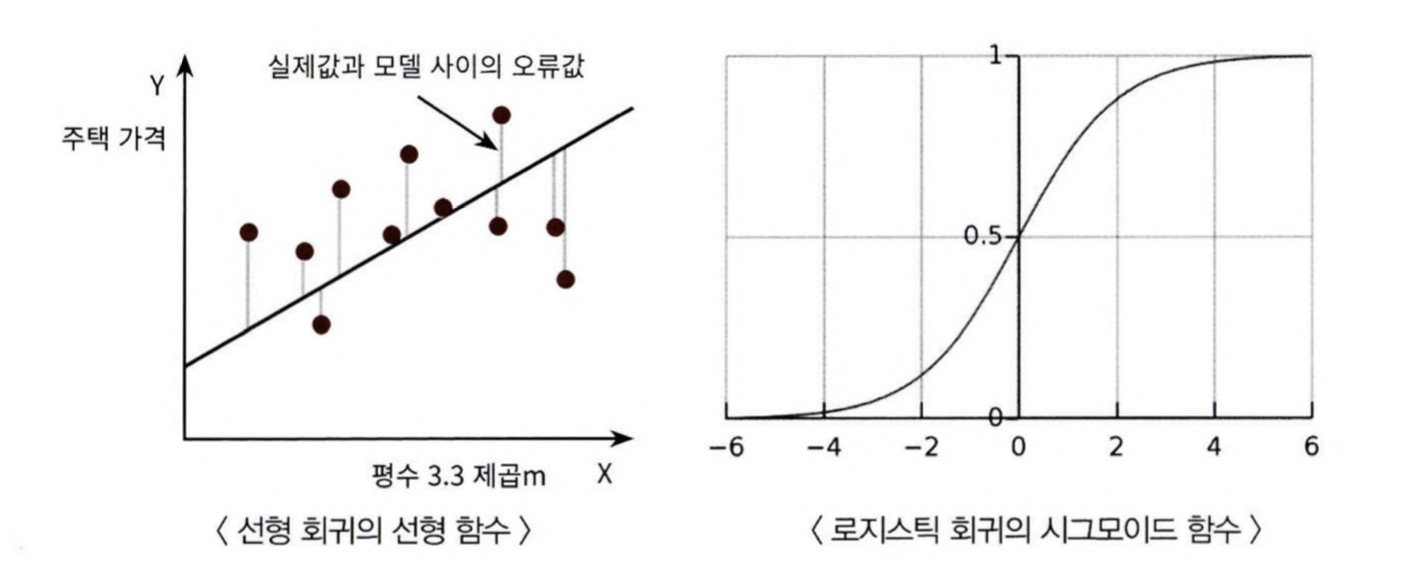




*   많은 자연, 사회 현상에서 특정 변수의 확률 값은 선형이 아니라 위의 시그모이드 함수와 같이 S자 커브 형태를 가진다. 시그모이드 함수의 정의는 y = 1 / (1+e^-x)이다. 위의 그림과 식에서 알 수 있듯이 시그모이드 함수는 x값이 +, -로 아무리 커지거나 작아져도 y값은 항상 0과 1 사이를 반환한다. x값이 커지면 1에 근사하며 x값이 작아지면 0에 근사하고, x가 0일 때는 0.5이다.
*   사이킷런은 로지스틱 회귀를 위해 LogisticRegression 클래스를 제공한다. LogisticRegression 클래스의 회귀 계수 최적화는 경사 하강법 외에도 다양한 최적화 방안이 있다. LogisticRegression 클래스에서 solver 파라미터의 'lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga' 값을 적용해 최적화를 선택할 수 있다.
*   lbfgs: 사이킷런 버전 0.22부터 solver의 기본 설정값이다. 메모리 공간을 절약할 수 있고, CPU 코어 수가 많다면 최적화를 병렬로 수행할 수 있다.
*   liblinear: 사이킷런 버전 0.21까지에서 solver의 기본 설정값이다. 다차원이고 작은 데이터 세트에서 효과적으로 동작하나, 국소 최적화(Local Minimum)에 이슈가 있으며 병렬로 최적화할 수 없다.
*   newton-cg: 좀 더 정교한 최적화를 가능하게 하나, 대용량의 데이터에서 속도가 많이 느려진다.
*   sag: Stochastic Average Gradient로, 경사 하강법 기반의 최적화를 적용한다. 대용량의 데이터에서 빠르게 최적화한다.
*   saga: sag과 유사한 최적화 방식이며, L1 정규화를 가능케 한다.
*   이렇게 다양한 solver값들이 있지만 이들간의 성능 차이는 미비하며, 일반적으로 lbfgs 또는 liblinear를 선택하는 것이 대부분이다.







In [25]:
## 사이킷런의 LogisticRegression 클래스를 이용해 위스콘신 유방암 데이터 세트 기반에서 로지스틱 회귀로 암 여부를 판단한다
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()  ## 전체 데이터를 생성한다



*   선형 회귀 계열의 로지스틱 회귀는 데이터의 정규 분포도에 따라 예측 성능 영향을 받을 수 있으므로, 데이터에 먼저 정규분포 형태의 표준 스케일링을 적용한 뒤, train_test_split()을 이용해 데이터 세트를 분리해야 한다.



In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
data_scaled = scaler.fit_transform(cancer.data)

X_train, X_test, y_train, y_test = train_test_split(data_scaled, cancer.target, test_size=0.3, random_state=0)

In [27]:
from sklearn.metrics import accuracy_score, roc_auc_score

## 로지스틱 회귀를 이용해 학습 및 예측 수행
## solver 인자값을 생성자로 입력하지 않으면 solver='lbfgs'
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_preds = lr_clf.predict(X_test)
lr_preds_proba = lr_clf.predict_proba(X_test)[:, 1]

## accuracy와 roc_auc를 측정한다
print('accuracy: {0:.3f}, roc_auc: {1:.3f}'.format(accuracy_score(y_test, lr_preds), roc_auc_score(y_test, lr_preds_proba)))

accuracy: 0.977, roc_auc: 0.995


solver가 lbfgs일 경우, 정확도가 0.977, ROC-AUC가 0.995로 도출되었다.

In [28]:
solvers = ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']

## 여러 개의 solver 값별로 LogisticRegression 학습 후 성능을 평가한다
for solver in solvers:
  lr_clf = LogisticRegression(solver = solver, max_iter=600)  ## 특정 solver는 최적화에 상대적으로 많은 반복 횟수가 필요할 수 있기 때문에 max_iter값을 600(큰 값)으로 설정한다
  lr_clf.fit(X_train, y_train)
  lr_preds = lr_clf.predict(X_test)
  lr_preds_proba = lr_clf.predict_proba(X_test)[:, 1]
  ## accuracy와 roc_auc를 측정한다
  print('solver:{0}, accuracy:{1:.3f}, roc_auc:{2:.3f}'.format(solver, accuracy_score(y_test, lr_preds), roc_auc_score(y_test, lr_preds_proba)))

solver:lbfgs, accuracy:0.977, roc_auc:0.995
solver:liblinear, accuracy:0.982, roc_auc:0.995
solver:newton-cg, accuracy:0.977, roc_auc:0.995
solver:sag, accuracy:0.982, roc_auc:0.995
solver:saga, accuracy:0.982, roc_auc:0.995


liblinear와 sag, saga일 때 정확도가 0.982, ROC-AUC가 0.995로 상대적인 성능 수치가 약간 높으나, 데이터 세트가 워낙 작기 때문에 개별 solver별 성능 결과의 차이는 크게 의미 있는 결과는 아니다.


*   solver와 max_iter 외에 사이킷런 LogisticRegression 클래스의 주요 하이퍼 파라미터로 penalty와 C가 있다. penalty는 규제(Regularization)의 유형을 설정하며 'l2'로 설정 시 L2 규제를, 'l1'으로 설정 시 L1 규제를 뜻한다. 기본은 'l2'이다. C는 규제 강도를 조절하는 alpha 값의 역수이다. 즉, C = 1/alpha이다. C 값이 작을수록 규제 강도가 크다.
*    L1, L2 규제의 경우 solver 설정에 따라 영향을 받는다. Liblinear, saga의 경우 L1, L2 규제가 모두 가능하지만, lbfgs, newton-cg, sag의 경우 L2 규제만 가능하다.



In [29]:
## GridSearchCV를 이용해 위스콘신 데이터 세트에서 solver, penalty, C를 최적화한다

from sklearn.model_selection import GridSearchCV

params = {'solver':['liblinear', 'lbfgs'], 'penalty':['l2', 'l1'], 'C':[0.01, 0.1, 1, 5, 10]}

lr_clf = LogisticRegression()

grid_clf = GridSearchCV(lr_clf, param_grid=params, scoring='accuracy', cv=3)
grid_clf.fit(data_scaled, cancer.target)
print('최적 하이퍼 파라미터:{0}, 최적 평균 정확도:{1:.3f}'.format(grid_clf.best_params_, grid_clf.best_score_))

최적 하이퍼 파라미터:{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}, 최적 평균 정확도:0.979


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solver

solver가 liblinear, Penalty가 L2 규제, C 값은 0.1일 때 평균 정확도가 0.979로 가장 좋은 성능을 나타낸다. (* FitFailedWarning 메시지는 solver가 lbfgs일 때 L1 규제를 지원하지 않음에도 GridSearchCV에서 L1 규제값을 입력했기 때문에 나오는 메시지이다.)


*   로지스틱 회귀는 가볍고 빠르나, 이진 분류 예측 성능도 뛰어나다. 이 때문에 로지스틱 회귀를 이진 분류의 기본 모델로 사용하는 경우가 많다. 또, 로지스틱 회귀는 희소한 데이터 세트 분류에도 뛰어난 성능을 보여서 텍스트 분류에서도 자주 사용된다.

## 회귀 트리
*   선형 회귀는 회귀 계수의 관계를 모두 선형으로 가정하는 방식이며, 일반적으로 회귀 계수를 선형으로 결합하는 회귀 함수를 구해 여기에 독립변수를 입력해 결괏값을 예측하는 것이다. 비선형 회귀 역시 비선형 회귀 함수를 통해 결괏값을 예측한다. 다만, 비선형 회귀는 회귀 계수의 결합이 비선형일 뿐이다.

*   트리 기반의 회귀는 회귀 트리를 이용하는 것, 즉 회귀를 위한 트리를 생성하고 이를 기반으로 회귀 예측을 하는 것이다. 회귀 트리는 분류트리와 크게 다르지 않다. (* 결정 트리, 랜덤 포레스트, GBM, XGBoost, LightGBM 등의 모든 트리 기반의 알고리즘은 분류뿐만 아니라 회귀도 가능하다. 트리 생성이 CART(Classification And Regression Trees) 알고리즘에 기반하고 있기 때문이다.) 다만 리프 노드에서 예측 결정 값을 만드는 과정에 차이가 있는데, 분류 트리가 특정 클래스 레이블을 결정하는 것과는 달리 회귀 트리는 리프 노드에 속한 데이터 값의 평균값을 구해 회귀 예측값을 계산한다.

*   사이킷런에서는 결정 트리, 랜덤 포레스트, GBM에서 CART 기반의 회귀 수행을 할 수 있는 Estimatior 클래스를 제공한다. 또, XGBoost, LightGBM도 사이킷런 래퍼 클래스를 통해 이를 제공한다.
KakaoTalk_20260511_004946605.jpg





In [33]:
## 사이킷런 랜덤 포레스트 회귀 트리인 RandomForestRegressor를 이용해 보스턴 주택 가격 예측을 수행한다
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

## 보스턴 데이터 세트를 로드한다
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]
X_data = pd.DataFrame(data)
y_target = pd.Series(target, name='PRICE')

rf = RandomForestRegressor(random_state=0, n_estimators=1000)
neg_mse_scores = cross_val_score(rf, X_data, y_target, scoring="neg_mean_squared_error", cv = 5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print('5 교차 검증의 개별 Negative MSE Scores: ', np.round(neg_mse_scores, 2))
print('5 교차 검증의 개별 RMSE Scores : ', np.round(rmse_scores, 2))
print('5 교차 검증의 평균 RMSE : ', np.round(avg_rmse))

5 교차 검증의 개별 Negative MSE Scores:  [ -7.88 -13.14 -20.57 -46.23 -18.88]
5 교차 검증의 개별 RMSE Scores :  [2.81 3.63 4.54 6.8  4.34]
5 교차 검증의 평균 RMSE :  4.0


In [34]:
## 랜덤 포레스트뿐만 아니라 결정 트리, GBM, XGBoost, LightGBM의 Regressor를 모두 이용해 보스턴 주택 가격 예측을 수행한다
## 입력 모델과 데이터 세트를 입력받아 교차 검증으로 평균 RMSE를 계산해주는 함수를 정의한다
def get_model_cv_prediction(model, X_data, y_target):
  neg_mse_scores = cross_val_score(model, X_data, y_target, scoring="neg_mean_squared_error", cv=5)
  rmse_scores = np.sqrt(-1 * neg_mse_scores)
  avg_rmse = np.mean(rmse_scores)
  print('##### ', model.__class__.__name__, ' #####')
  print(' 5 교차 검증의 평균 RMSE: {0:.3f}'.format(avg_rmse))

In [35]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

dt_reg = DecisionTreeRegressor(random_state=0, max_depth=4)
rf_reg = RandomForestRegressor(random_state=0, n_estimators=1000)
gb_reg = GradientBoostingRegressor(random_state=0, n_estimators=1000)
xgb_reg = XGBRegressor(random_state=0, n_estimators=1000)
lgb_reg = LGBMRegressor(random_state=0, n_estimators=1000)

## 트리 기반의 회귀 모델을 반복하면서 평가를 수행한다
models = [dt_reg, rf_reg, gb_reg, xgb_reg, lgb_reg]
for model in models:
  get_model_cv_prediction(model, X_data, y_target)

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 



*   회귀 트리 Regressor 클래스는 선형 회귀와 다른 처리 방식이므로 회귀 계수를 제공하는 coef_ 속성이 없다. 대신 feature_importances_를 이용해 피처별 중요도를 알 수 있다.



<Axes: xlabel='None', ylabel='None'>

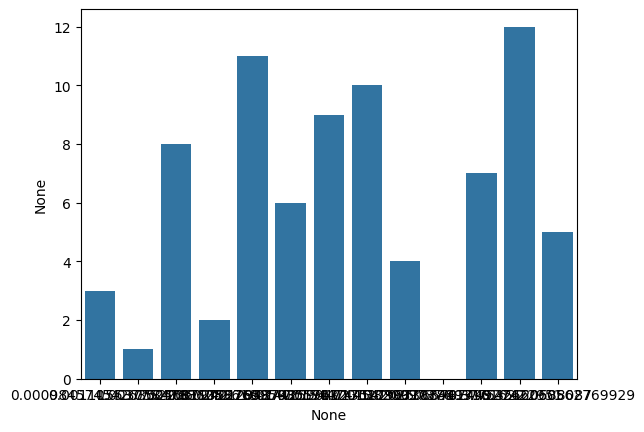

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

rf_reg = RandomForestRegressor(random_state=0, n_estimators=1000)

## 앞 예제에서 만들어진 X_data, y_target 데이터 세트를 적용해 학습한다
rf_reg.fit(X_data, y_target)

feature_series = pd.Series(data=rf_reg.feature_importances_, index=X_data.columns)
feature_series = feature_series.sort_values(ascending=False)
sns.barplot(x=feature_series, y=feature_series.index)

(100, 2)


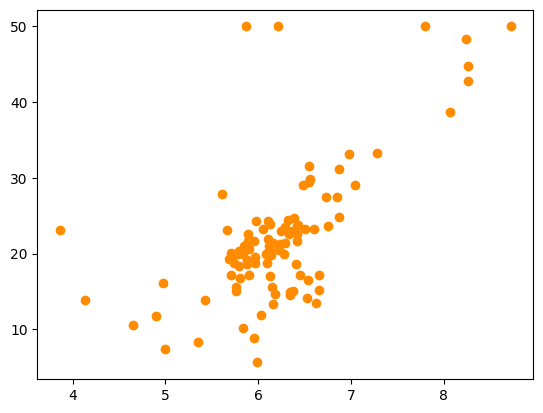

In [39]:
## 회귀 트리 Regressor가 어떻게 예측값을 판단하는지 선형 회귀와 비교해 시각화한다

feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
X_data.columns = feature_names
bostonDF = pd.concat([X_data, y_target], axis=1)

bostonDF_sample = bostonDF[['RM', 'PRICE']]
bostonDF_sample = bostonDF_sample.sample(n=100, random_state=0)
print(bostonDF_sample.shape)
plt.figure()
plt.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c="darkorange")

In [41]:
import numpy as np
from sklearn.linear_model import LinearRegression

## 선형 회귀와 결정 트리 기반의 Regressor을 생성한다. 이 때 DecisionTreeRegressor의 max_depth는 각각 2, 7이다
lr_reg = LinearRegression()
rf_reg2 = DecisionTreeRegressor(max_depth=2)
rf_reg7 = DecisionTreeRegressor(max_depth=7)

## 실제 예측을 적용할 테스트용 데이터 세트를 4.5 ~ 8.5까지의 100개의 데이터 세트로 생성한다
X_test = np.linspace(4.5, 8.5, 100).reshape(-1, 1)

## 보스턴 주택 가격 데이터에서 시각화를 위해 피처는 RM만, 그리고 결정 데이터인 PRICE를 추출한다
X_feature = bostonDF_sample['RM'].values.reshape(-1, 1)
y_target = bostonDF_sample['PRICE'].values.reshape(-1, 1)

## 학습과 예측을 수행한다
lr_reg.fit(X_feature, y_target)
rf_reg2.fit(X_feature, y_target)
rf_reg7.fit(X_feature, y_target)

pred_lr = lr_reg.predict(X_test)
pred_rf2 = rf_reg2.predict(X_test)
pred_rf7 = rf_reg7.predict(X_test)

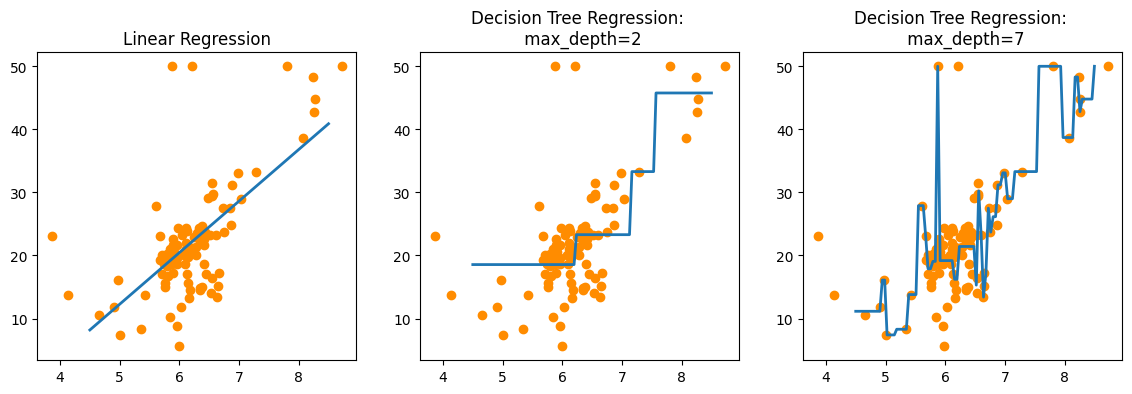

In [42]:
fig, (ax1, ax2, ax3) = plt.subplots(figsize=(14, 4), ncols=3)

## X축 값을 4.5 ~ 8.5로 변환하며 입력했을 때의 선형 회귀와 결정 트리 회귀 예측선을 시각화한다
## 선형 회귀로 학습된 모델 회귀 예측선
ax1.set_title('Linear Regression')
ax1.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c="darkorange")
ax1.plot(X_test, pred_lr, label="linear", linewidth=2)

## DecisionTreeRegressor의 max_depth를 2로 했을 때 회귀 예측선
ax2.set_title('Decision Tree Regression: \n max_depth=2')
ax2.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c="darkorange")
ax2.plot(X_test, pred_rf2, label="max_depth=3", linewidth=2)

## DecisionTreeRegressor의 max_depth를 7로 했을 때 회귀 예측선
ax3.set_title('Decision Tree Regression: \n max_depth=7')
ax3.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c="darkorange")
ax3.plot(X_test, pred_rf7, label="max_depth=7", linewidth=2)

선형 회귀는 직선으로 예측 회귀선을 표현하는 데에 반해, 회귀 트리의 경우 분할되는 데이터 지점에 따라 브랜치를 만들면서 계단 형태로 회귀선을 만든다. DecisionTreeRegressor의 max_depth=7인 경우에는 학습 데이터 세트의 이상치 데이터도 학습하면서 복잡한 계단 형태의 회귀선을 만들어 과적합이 되기 쉬운 모델이 되었음을 알 수 있다.